### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import TargetEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

### Configurations

In [2]:
data_path = "data/main.csv"

## Exploratory Data Analysis

In [3]:
db_main = pd.read_csv(data_path)
db_main.head()

C:\Users\ApoorvTripathi\AppData\Local\Temp\ipykernel_14420\3709795038.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  db_main = pd.read_csv(data_path)


,health_service_area,hospital_county,operating_certificate_number,facility_id,facility_name,age_group,zip_code_3_digits,gender,race,ethnicity,...,apr_risk_of_mortality,apr_medical_surgical_description,payment_typology_1,birth_weight,abortion_edit_indicator,emergency_department_indicator,total_charges,total_costs,payment_typology_2,payment_typology_3
0,New York City,Bronx,7000001,1164,Bronx-Lebanon Hospital Center - Fulton Division,30 to 49,114,M,Other Race,Spanish/Hispanic,...,Minor,Medical,Medicaid,0,N,Y,8225.00,7341.60,NaN,NaN
1,New York City,Bronx,7000002,1165,Jacobi Medical Center,30 to 49,104,M,Black/African American,Not Span/Hispanic,...,Minor,Medical,Medicaid,0,N,Y,4846.76,2801.79,NaN,NaN
2,New York City,Bronx,7000002,1165,Jacobi Medical Center,0 to 17,104,M,Other Race,Spanish/Hispanic,...,Minor,Medical,Medicaid,0,N,Y,17205.30,9945.95,Medicaid,NaN
3,New York City,Bronx,7000002,1165,Jacobi Medical Center,30 to 49,104,F,Black/African American,Not Span/Hispanic,...,Minor,Medical,Medicaid,0,N,Y,9132.22,5279.11,NaN,NaN
4,New York City,Bronx,7000002,1165,Jacobi Medical Center,0 to 17,104,F,Other Race,Spanish/Hispanic,...,Minor,Medical,Medicaid,0,N,Y,6645.30,3841.48,NaN,NaN


In [4]:
print(db_main.shape)

(100000, 34)


In [5]:
db_main.describe()

,operating_certificate_number,facility_id,discharge_year,ccs_diagnosis_code,ccs_procedure_code,apr_drg_code,apr_mdc_code,apr_severity_of_illness_code,birth_weight,total_charges,total_costs
count,1.000000e+05,100000.000000,100000.0,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,1.000000e+05,1.000000e+05
mean,7.000005e+06,1168.410790,2016.0,194.508910,119.614520,395.261430,9.812920,2.025170,197.16400,5.464383e+04,1.779180e+04
std,2.124291e+00,2.368058,0.0,172.755464,95.867214,250.801868,6.145606,0.862777,779.24491,1.037405e+05,3.441911e+04
min,7.000001e+06,1164.000000,2016.0,1.000000,0.000000,1.000000,1.000000,1.000000,0.00000,2.000000e-02,0.000000e+00
25%,7.000006e+06,1168.000000,2016.0,102.000000,0.000000,192.000000,5.000000,1.000000,0.00000,1.378721e+04,5.230290e+03
50%,7.000006e+06,1169.000000,2016.0,146.000000,135.000000,344.000000,8.000000,2.000000,0.00000,2.905974e+04,9.428420e+03
75%,7.000006e+06,1169.000000,2016.0,218.000000,219.000000,640.000000,15.000000,3.000000,0.00000,5.857594e+04,1.864828e+04
max,7.000014e+06,1178.000000,2016.0,999.000000,999.000000,952.000000,25.000000,4.000000,6600.00000,5.031496e+06,2.908582e+06


In [6]:
db_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 34 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   health_service_area                  100000 non-null  object 
 1   hospital_county                      100000 non-null  object 
 2   operating_certificate_number         100000 non-null  int64  
 3   facility_id                          100000 non-null  int64  
 4   facility_name                        100000 non-null  object 
 5   age_group                            100000 non-null  object 
 6   zip_code_3_digits                    98415 non-null   object 
 7   gender                               100000 non-null  object 
 8   race                                 100000 non-null  object 
 9   ethnicity                            100000 non-null  object 
 10  length_of_stay                       100000 non-null  object 
 11  type_of_admiss

In [7]:
columns_for_the_table = [
    "health_service_area", 
    "age_group", 
    "gender", 
    "race", 
    "type_of_admission", 
    "patient_disposition", 
    "ccs_diagnosis_code", 
    "ccs_procedure_code", 
    "apr_drg_code", 
    "apr_mdc_code", 
    "apr_severity_of_illness_code", 
    "apr_risk_of_mortality", 
    "birth_weight", 
    "abortion_edit_indicator", 
    "emergency_department_indicator", 
    "length_of_stay"
]

### Selecting the features which are intuitively more important for the model and removing non relevant ones like payment and description features.

In [8]:
db = db_main[columns_for_the_table]
db.head()

,health_service_area,age_group,gender,race,type_of_admission,patient_disposition,ccs_diagnosis_code,ccs_procedure_code,apr_drg_code,apr_mdc_code,apr_severity_of_illness_code,apr_risk_of_mortality,birth_weight,abortion_edit_indicator,emergency_department_indicator,length_of_stay
0,New York City,30 to 49,M,Other Race,Emergency,Home or Self Care,657,0,753,19,1,Minor,0,N,Y,3
1,New York City,30 to 49,M,Black/African American,Emergency,Home or Self Care,657,218,753,19,1,Minor,0,N,Y,3
2,New York City,0 to 17,M,Other Race,Emergency,Home or Self Care,128,231,141,4,2,Minor,0,N,Y,3
3,New York City,30 to 49,F,Black/African American,Emergency,Home or Self Care,657,218,753,19,1,Minor,0,N,Y,6
4,New York City,0 to 17,F,Other Race,Emergency,Home or Self Care,128,231,141,4,1,Minor,0,N,Y,1


## Split data into training and testing dataset

In [9]:
# Split the Features and Target columns
x = db.iloc[:,:-1]
y = db.iloc[:,-1]

# Fix the data type of the traget column
y = y.astype(str).str.replace("+", "", regex=False).str.strip().astype(int)

# Split the data into training and test dataset
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

### Check Null Values

In [10]:
db.isna().sum()

health_service_area               0
age_group                         0
gender                            0
race                              0
type_of_admission                 0
patient_disposition               0
ccs_diagnosis_code                0
ccs_procedure_code                0
apr_drg_code                      0
apr_mdc_code                      0
apr_severity_of_illness_code      0
apr_risk_of_mortality             0
birth_weight                      0
abortion_edit_indicator           0
emergency_department_indicator    0
length_of_stay                    0
dtype: int64

### Check the destribution of each feature

### Destribution of categorical data

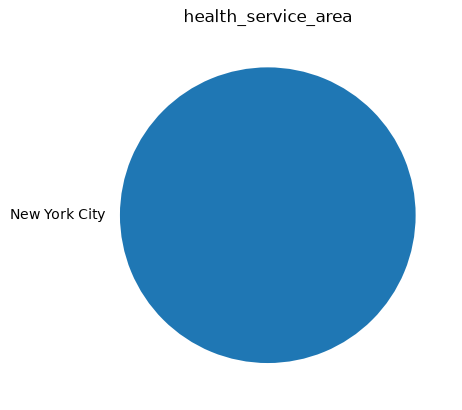

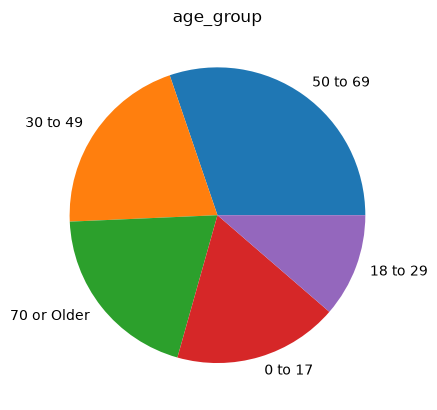

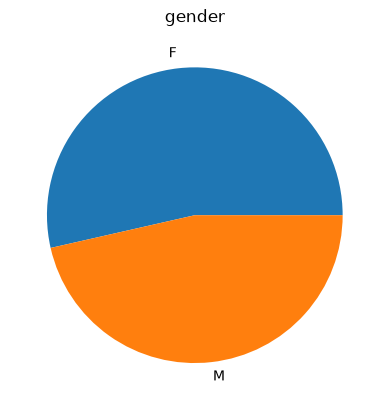

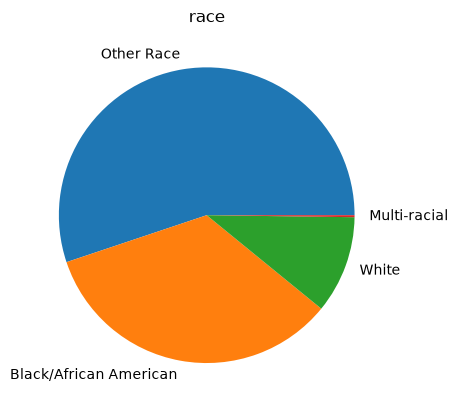

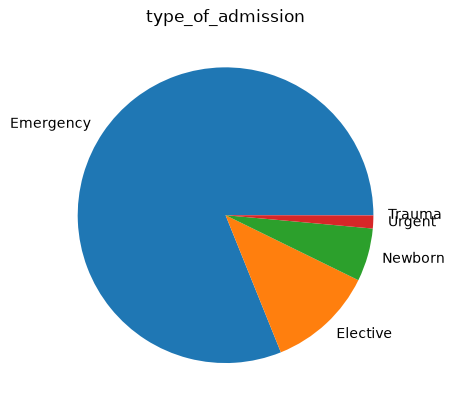

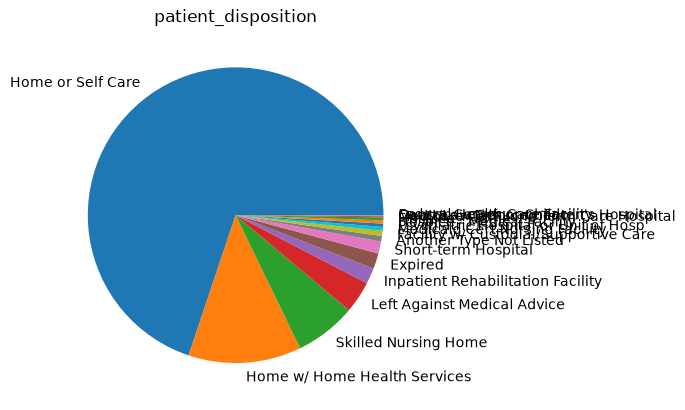

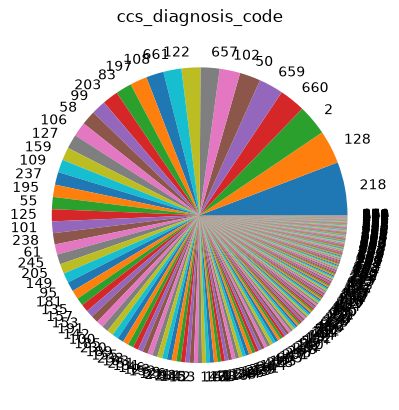

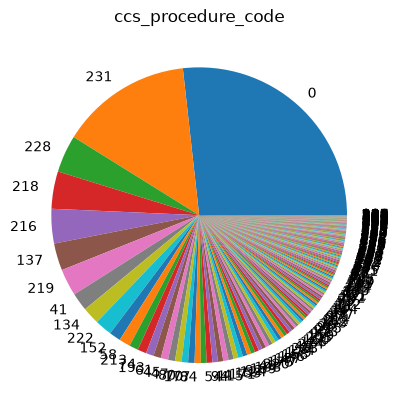

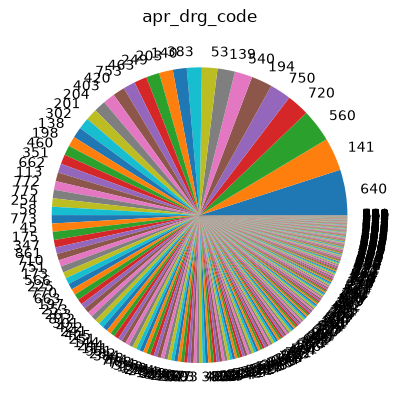

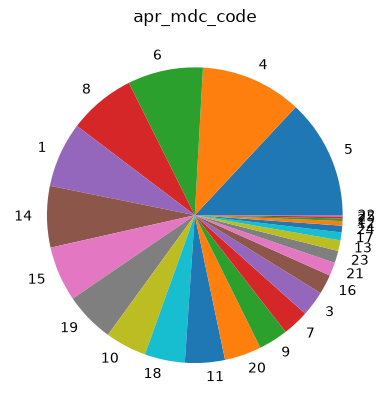

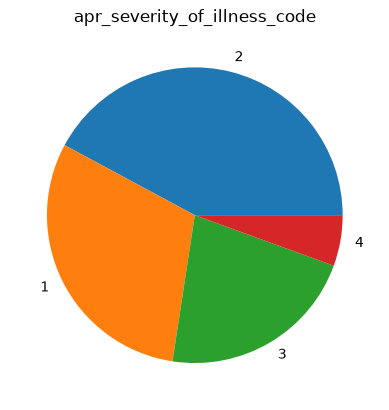

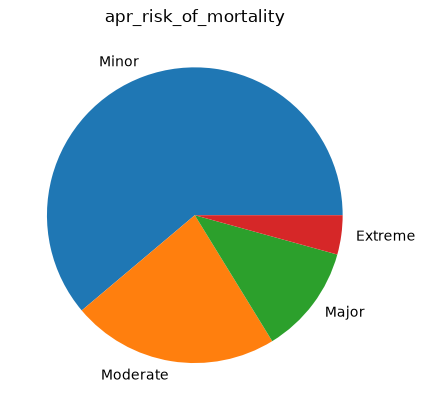

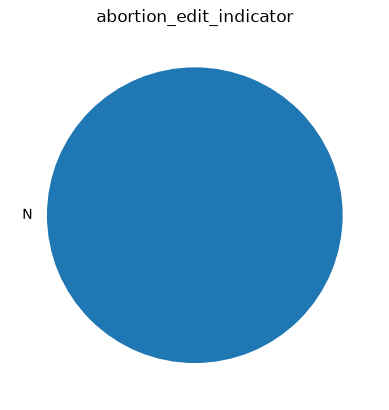

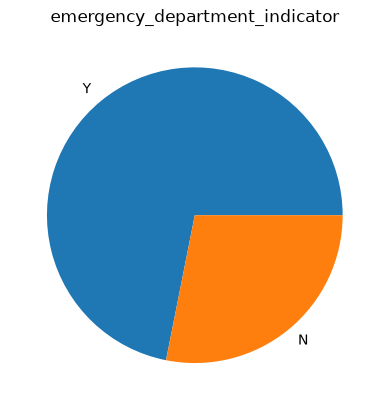

In [11]:
plots_to_make = [
    "health_service_area",
    "age_group",
    "gender",
    "race",
    "type_of_admission",
    "patient_disposition",
    "ccs_diagnosis_code",
    "ccs_procedure_code",
    "apr_drg_code",
    "apr_mdc_code",
    "apr_severity_of_illness_code",
    "apr_risk_of_mortality",
    "abortion_edit_indicator",
    "emergency_department_indicator"
]
for i in plots_to_make:
    counts_for_hs = db[i].value_counts()
    labels = counts_for_hs.index
    values = counts_for_hs.values

# Plot the chart
    plt.pie(values, labels=labels)
    plt.title(i)
    plt.show()

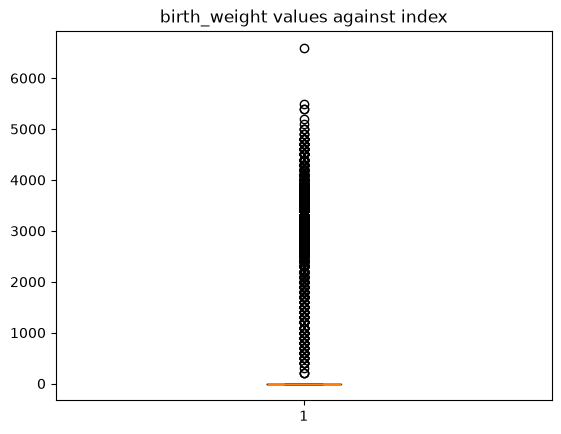

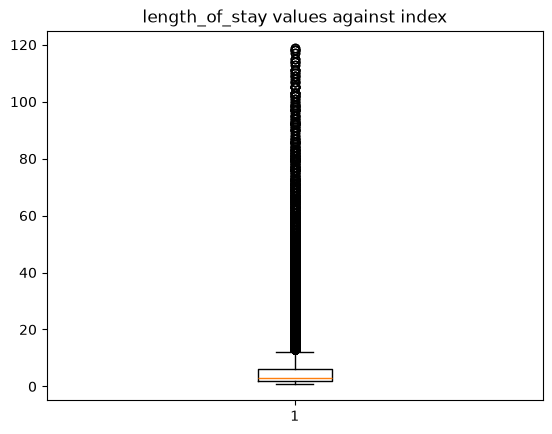

In [12]:
plots_to_make_numerical = ["birth_weight", "length_of_stay"]
for i in plots_to_make_numerical:
    col = pd.to_numeric(db[i], errors='coerce').dropna()
    plt.boxplot(col)
    plt.title(f"{i} values against index")
    plt.show()

In [13]:
codes_features = ["ccs_diagnosis_code", "ccs_procedure_code", "apr_drg_code", "apr_mdc_code"]
for i in codes_features:
    print(f"Unique categories in {i}: {db[i].nunique()}")

Unique categories in ccs_diagnosis_code: 257
Unique categories in ccs_procedure_code: 218
Unique categories in apr_drg_code: 311
Unique categories in apr_mdc_code: 25


1. Scale Birth weight
2. One Hot Encode Features
3. Normalize birth weight column
4. Handle Codes features

### Create a column transformer which will be used for streamlining the One-Hot and Target encoding process.

In [14]:
columns_for_one_hot_encoder = [
    "health_service_area",
    "age_group",
    "gender",
    "race",
    "type_of_admission",
    "patient_disposition",
    "ccs_diagnosis_code",
    "ccs_procedure_code",
    "apr_drg_code",
    "apr_mdc_code",
    "apr_severity_of_illness_code",
    "apr_risk_of_mortality",
    "abortion_edit_indicator",
    "emergency_department_indicator"
]
columns_for_target_encoder = ["ccs_diagnosis_code", "ccs_procedure_code", "apr_drg_code", "apr_mdc_code"]

encoded_columns = ColumnTransformer(transformers=[
    ("one_hot_encoder", OneHotEncoder(handle_unknown='ignore', sparse_output=False),columns_for_one_hot_encoder),
    ("target_encoder", TargetEncoder(target_type='continuous',smooth='auto',cv=5),columns_for_target_encoder)
], verbose_feature_names_out=True, remainder="passthrough")

### Creating the Pipeline

In [15]:
pipe = Pipeline([("embeded_columns", encoded_columns)])
pipe.set_output(transform="pandas")

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('embeded_columns', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('one_hot_encoder', ...), ('target_encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, 

### Passing data through the pipeline and saving the csv's 

In [16]:
x_train = pipe.fit_transform(x_train,y_train)
x_test = pipe.transform(x_test)

In [17]:
x_test.to_csv("data/x_test.csv", index=False)
y_test.to_csv("data/y_test.csv", index=False)
x_train.to_csv("data/x_train.csv", index=False)
y_train.to_csv("data/y_train.csv", index=False)